# Mô Phỏng Máy Hút Bụi (Vacuum Cleaner Agent) sử dụng AND-OR Graph Search

**Quy ước ma trận:**
- `0` → Ô trống (sạch) / Máy hút bụi
- `1` → Bụi

**Thuật toán: AND-OR Graph Search**
- Thuật toán này được áp dụng cho **môi trường không xác định (non-deterministic)** nhưng có thể quan sát toàn bộ (fully observable).
- Agent không tìm kiếm một chuỗi hành động tuyến tính cố định, mà tìm kiếm một **kế hoạch điều kiện (conditional plan)** (hoặc một chính sách - policy). Kế hoạch này chứa các nhánh để đối phó với mọi tình huống ngẫu nhiên xảy ra từ môi trường.
- Để minh họa, ta giả định hành động **HÚT (SUCK)** có tính không xác định:
  - Có thể chỉ hút sạch bụi tại ô hiện tại (xác suất 50%).
  - Hoặc hút sạch bụi tại ô hiện tại đồng thời hút sạch thêm bụi ở ô kề cận (xác suất 50% nếu có ô kề cận chứa bụi).
- **Lưu ý về kích thước lưới (Grid Size):** Vì AND-OR Graph Search giải quyết tất cả các nhánh kịch bản của không gian trạng thái, số lượng trạng thái tăng theo cấp số nhân ($O(N \cdot 2^N)$ với $N$ là số ô lưới). Do đó, để tránh bùng nổ tổ hợp và đảm bảo thời gian chạy trong thời gian thực, chúng ta thiết lập kích thước lưới nhỏ ($3 	imes 3$ hoặc $2 	imes 3$) thay vì lưới lớn.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import time
from IPython.display import clear_output

Ma trận ban đầu  |  Tổng bụi: 8 ô


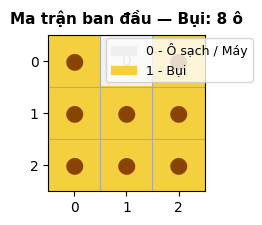

In [2]:
# ── Cấu hình môi trường ──
ROWS      = 3
COLS      = 3
DUST_PROB = 0.5  # Xác suất sinh bụi tại mỗi ô

# ── Tạo môi trường ──
def create_env(rows, cols, dust_prob):
    grid = np.zeros((rows, cols), dtype=int)
    for r in range(rows):
        for c in range(cols):
            if random.random() < dust_prob:
                grid[r][c] = 1
    return grid

# ── Vẽ ma trận ──
def draw_grid(grid, pos, title):
    rows, cols = grid.shape
    fig, ax = plt.subplots(figsize=(cols * 0.9, rows * 0.9))

    cmap = ListedColormap(['#F0F0F0', '#F4D03F'])  # 0=xám nhạt, 1=vàng
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=1)

    for r in range(rows):
        for c in range(cols):
            if (r, c) == pos:
                ax.text(c, r, '🤖', ha='center', va='center', fontsize=14)
            elif grid[r][c] == 1:
                ax.text(c, r, '●', ha='center', va='center',
                        fontsize=16, color='#884400')
            else:
                ax.text(c, r, '0', ha='center', va='center',
                        fontsize=11, color='#888888')

    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    ax.set_xticklabels(np.arange(cols))
    ax.set_yticklabels(np.arange(rows))
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='#AAAAAA', linewidth=0.8)
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    legend = [
        mpatches.Patch(color='#F0F0F0', label='0 - Ô sạch / Máy'),
        mpatches.Patch(color='#F4D03F', label='1 - Bụi'),
    ]
    ax.legend(handles=legend, loc='upper right',
              bbox_to_anchor=(1.35, 1.02), fontsize=9)

    plt.tight_layout()
    plt.show()

# ── Khởi tạo môi trường ban đầu ──
grid = create_env(ROWS, COLS, DUST_PROB)
total_dust = int(np.sum(grid == 1))

# Đảm bảo có ít nhất một ô có bụi để minh họa tìm kiếm
while total_dust == 0:
    grid = create_env(ROWS, COLS, DUST_PROB)
    total_dust = int(np.sum(grid == 1))

print(f"Ma trận ban đầu  |  Tổng bụi: {total_dust} ô")
draw_grid(grid, pos=(-1, -1), title=f'Ma trận ban đầu — Bụi: {total_dust} ô')

In [3]:
# ── Định nghĩa lớp bài toán hút bụi không xác định (Nondeterministic Vacuum Problem) ──
class VacuumProblem:
    def __init__(self, initial_state):
        self.initial = initial_state # State: ((r, c), grid_tuple)
        
    def goal_test(self, state):
        pos, grid_tuple = state
        return sum(sum(row) for row in grid_tuple) == 0
        
    def actions(self, state):
        pos, grid_tuple = state
        r, c = pos
        rows = len(grid_tuple)
        cols = len(grid_tuple[0])
        
        acts = []
        # Ưu tiên hành động HÚT trước nếu tại ô hiện tại có bụi
        if grid_tuple[r][c] == 1:
            acts.append('HÚT')
            
        # Các hành động di chuyển hợp lệ
        if r > 0: acts.append('LÊN')
        if r < rows - 1: acts.append('XUỐNG')
        if c > 0: acts.append('TRÁI')
        if c < cols - 1: acts.append('PHẢI')
        
        return acts
        
    def results(self, state, action):
        pos, grid_tuple = state
        r, c = pos
        rows = len(grid_tuple)
        cols = len(grid_tuple[0])
        
        if action == 'HÚT':
            # Hành động HÚT không xác định:
            # Kết quả 1: Chỉ hút sạch bụi ở ô hiện tại
            grid_list = [list(row) for row in grid_tuple]
            grid_list[r][c] = 0
            outcome1 = ((r, c), tuple(tuple(row) for row in grid_list))
            
            # Kết quả 2: Hút sạch bụi ô hiện tại và một ô kề cận có bụi (nếu có)
            adjacents = []
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < rows and 0 <= nc < cols:
                    if grid_tuple[nr][nc] == 1:
                        adjacents.append((nr, nc))
            
            if adjacents:
                outcomes = [outcome1]
                for ar, ac in adjacents:
                    grid_list_adj = [list(row) for row in grid_tuple]
                    grid_list_adj[r][c] = 0
                    grid_list_adj[ar][ac] = 0
                    outcomes.append(((r, c), tuple(tuple(row) for row in grid_list_adj)))
                unique_outcomes = []
                for out in outcomes:
                    if out not in unique_outcomes:
                        unique_outcomes.append(out)
                return unique_outcomes
            else:
                return [outcome1]
                
        else:
            # Hành động di chuyển là xác định để tránh tạo các chu trình không hồi kết
            offsets = {
                'LÊN': (-1, 0),
                'XUỐNG': (1, 0),
                'TRÁI': (0, -1),
                'PHẢI': (0, 1)
            }
            dr, dc = offsets[action]
            intended_pos = (r + dr, c + dc)
            return [(intended_pos, grid_tuple)]

In [4]:
# ── Cài đặt thuật toán AND-OR Graph Search ──
def and_or_graph_search(problem):
    """Tìm kiếm đồ thị AND-OR (AIMA Figure 4.11) để tạo ra kế hoạch điều kiện."""
    return or_search(problem.initial, problem, [])

def or_search(state, problem, path):
    if problem.goal_test(state):
        return []
    if state in path:
        return None
    for action in problem.actions(state):
        plan = and_search(problem.results(state, action), problem, path + [state])
        if plan is not None:
            return (action, plan)
    return None

def and_search(states, problem, path):
    plan = {}
    for s in states:
        plan_s = or_search(s, problem, path)
        if plan_s is None:
            return None
        plan[s] = plan_s
    return plan

In [5]:
# ── Hàm chạy Agent và mô phỏng trực quan ──
def run_agent_and_or(grid_in):
    grid = grid_in.copy()
    rows, cols = grid.shape
    start_pos = (0, 0)
    
    # Chuyển đổi lưới sang dạng tuple để tạo trạng thái
    grid_tuple = tuple(tuple(row) for row in grid)
    initial_state = (start_pos, grid_tuple)
    
    problem = VacuumProblem(initial_state)
    
    print("Đang chạy AND-OR Graph Search để tìm kế hoạch điều kiện...")
    plan = and_or_graph_search(problem)
    
    if plan is None:
        print("THẤT BẠI: Không tìm thấy kế hoạch điều kiện khả thi cho ma trận này!")
        return
        
    print("Đã tìm thấy kế hoạch điều kiện thành công! Bắt đầu mô phỏng trực quan...")
    time.sleep(2.0)
    
    curr_state = initial_state
    curr_plan = plan
    steps = 0
    total_dust = int(np.sum(grid == 1))
    cleaned = 0
    
    # Vẽ giao diện ban đầu
    clear_output(wait=True)
    draw_grid(grid, pos=start_pos, title=f"Khởi đầu tại {start_pos} | Bụi còn lại: {total_dust - cleaned}/{total_dust}")
    time.sleep(1.0)
    
    while curr_plan != []:
        action, subplans = curr_plan
        steps += 1
        pos, grid_tuple = curr_state
        r, c = pos
        
        action_desc = "HÚT BỤI" if action == "HÚT" else f"Di chuyển {action}"
        print(f"Bước {steps}: Đang thực hiện hành động -> {action_desc}")
        
        # Môi trường phản hồi ngẫu nhiên (non-deterministic)
        possible_states = problem.results(curr_state, action)
        next_state = random.choice(possible_states)
        next_pos, next_grid_tuple = next_state
        
        # Cập nhật môi trường hiển thị thực tế
        grid = np.array(next_grid_tuple)
        curr_dust = int(np.sum(grid == 1))
        cleaned = total_dust - curr_dust
        
        # Cập nhật UI
        clear_output(wait=True)
        title_msg = f"Bước {steps} | {action_desc} -> Vị trí: {next_pos} | Bụi đã hút: {cleaned}/{total_dust}"
        draw_grid(grid, pos=next_pos, title=title_msg)
        time.sleep(1.0)
        
        # Tiến tới bước tiếp theo trong kế hoạch điều kiện
        curr_state = next_state
        curr_plan = subplans[next_state]
        
    print('=' * 45)
    if cleaned == total_dust:
        status = 'THÀNH CÔNG'
        reason = 'Đã quét và hút sạch hết bụi theo kế hoạch điều kiện!'
    else:
        status = 'THẤT BẠI'
        reason = 'Chưa làm sạch hết bụi trên lưới'
        
    print(f'Số bước đi  : {steps}')
    print(f'Bụi đã hút  : {cleaned} / {total_dust} ô')
    print(f'Trạng thái  : {status}')
    print(f'Lý do       : {reason}\n')

C:\Users\viet0\AppData\Local\Temp\ipykernel_6884\3136326746.py:51: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Lab_AI\Lab_AI\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


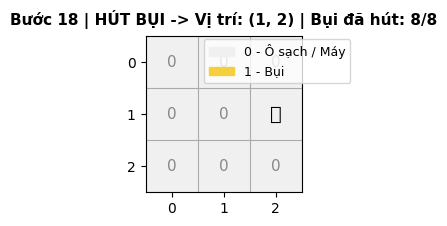

Số bước đi  : 18
Bụi đã hút  : 8 / 8 ô
Trạng thái  : THÀNH CÔNG
Lý do       : Đã quét và hút sạch hết bụi theo kế hoạch điều kiện!



In [6]:
run_agent_and_or(grid)